In [1]:
import pandas as pd
import duckdb
import matplotlib.pyplot as plt

In [2]:
# Load the dataset
df_gdg_totals_by_country = pd.read_excel("sample_data/EDGAR_2025_GHG_booklet_2025.xlsx", sheet_name='GHG_totals_by_country')
df_gdg_totals_by_country.head()

,EDGAR Country Code,Country,1970,1971,1972,1973,1974,1975,1976,1977,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,ABW,Aruba,0.036970,0.041825,0.052708,0.057704,0.056999,0.071134,0.070200,0.081045,...,0.491516,0.515073,0.496688,0.494967,0.540013,0.519081,0.538335,0.567492,0.569503,0.588716
1,AFG,Afghanistan,15.299964,15.221080,13.278752,13.972049,15.242002,15.968872,16.124561,16.187783,...,28.093085,27.164741,30.474595,31.935810,32.436168,32.400168,32.835846,31.912139,32.435107,33.034840
2,AGO,Angola,18.834350,18.721850,21.316779,22.878757,23.586101,22.421772,18.464447,23.132615,...,83.536858,80.625508,75.433643,70.465116,71.208749,63.159221,66.601919,68.035237,68.280785,69.922939
3,AIA,Anguilla,0.003398,0.003448,0.003595,0.003480,0.003771,0.004051,0.003920,0.004053,...,0.031418,0.031813,0.032561,0.031682,0.031037,0.026125,0.025314,0.025156,0.025158,0.026035
4,AIR,International Aviation,172.478016,172.465447,182.459826,190.296915,183.162106,177.165834,177.483078,193.593367,...,543.596041,567.905926,597.733372,623.932398,633.217053,299.636334,330.748407,477.751478,578.330736,622.334162


In [3]:
# Reshape the data (Pivot from wide to long)
melted_df = df_gdg_totals_by_country.melt(id_vars=['Country'],
                            value_vars=[year for year in range(1970, 2025)],
                            var_name='Year', value_name='GHG_Total')

# Ensure Year is numeric for the x-axis
melted_df['Year'] = melted_df['Year'].astype(int)
melted_df.head()

,Country,Year,GHG_Total
0,Aruba,1970,0.036970
1,Afghanistan,1970,15.299964
2,Angola,1970,18.834350
3,Anguilla,1970,0.003398
4,International Aviation,1970,172.478016


In [4]:
# Filter top 10 countries by GHG emissions

df_top_10_countries_by_ghg = duckdb.query("""
                              SELECT Country, SUM(GHG_Total) AS GHG_Total
                              FROM melted_df
                              WHERE Country NOT IN ('GLOBAL TOTAL', 'EU27')
                              GROUP BY Country
                              ORDER BY GHG_Total
                              DESC LIMIT 10
                              """).to_df()
df_top_10_countries_by_ghg

,Country,GHG_Total
0,China,373558.542708
1,United States,349160.181380
2,Russia,127331.841999
3,India,108415.659594
4,Japan,68196.105349
5,Germany,60537.614032
6,Brazil,45796.846995
7,United Kingdom,38176.318976
8,Canada,36420.928003
9,Ukraine,31899.216607


In [5]:
# Select specific countries and extract list
countries_to_plot = df_top_10_countries_by_ghg['Country'].to_list()
countries_to_plot

['China',
 'United States',
 'Russia',
 'India',
 'Japan',
 'Germany',
 'Brazil',
 'United Kingdom',
 'Canada',
 'Ukraine']

In [9]:
filtered_df = melted_df[melted_df['Country'].isin(countries_to_plot)]
print(df_gdg_totals_by_country.shape)
print(melted_df.shape)
print(filtered_df.shape)

(214, 57)
(11770, 3)
(550, 3)


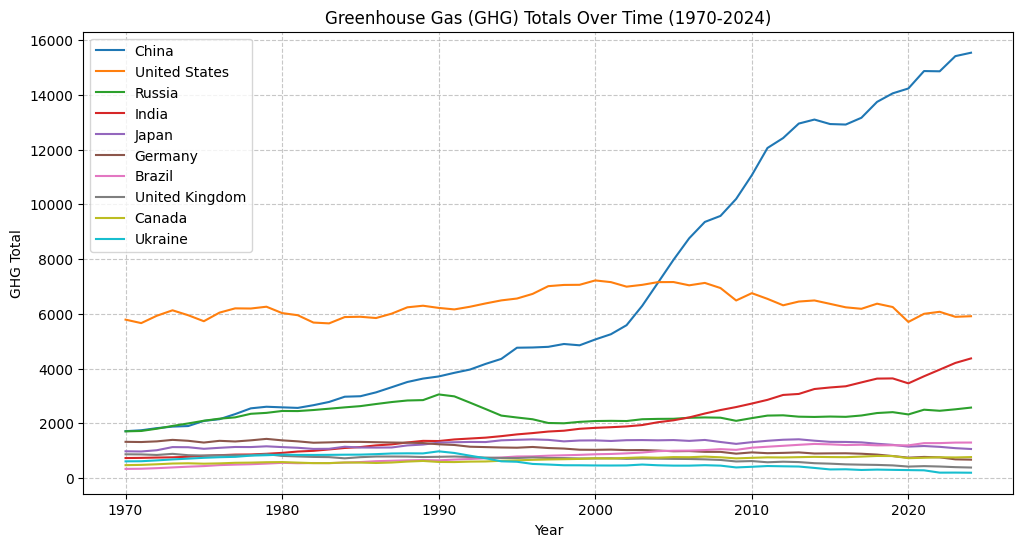

In [7]:
# 5. Create the plot
plt.figure(figsize=(12, 6))

for country in countries_to_plot:
    subset = filtered_df[filtered_df['Country'] == country]
    plt.plot(subset['Year'], subset['GHG_Total'], label=country)

# 6. Customize the chart
plt.title('Greenhouse Gas (GHG) Totals Over Time (1970-2024)')
plt.xlabel('Year')
plt.ylabel('GHG Total')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# 7. Display or save the result
plt.savefig('ghg_line_chart.png')
plt.show()